# Autoencoders for Image Restoration
### Student: Clițan Alexandru Ioan
### Course: Software for Signal and Image Processing
This project explores the use of convolutional autoencoders for restoring corrupted images.


### Imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
import random
import time

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

print("Modules imported successfully!")

Modules imported successfully!


### Data loader
Load Fashion-MNIST dataset and normalize images to [0, 1]


In [2]:
def load_data():

    print("Loading Fashion_MNIST dataset...\n")
    # Input = image, Output = image, _ = ignore labels
    (x_train, _), (x_test, _) = fashion_mnist.load_data()

    # Normalize between [0, 1]
    x_train = x_train.astype('float32') / 255.0
    x_test = x_test.astype('float32') / 255.0

    # Manually adding channel dimension (grayscale) => 4D
    x_train = x_train[..., None]  # (N, 28, 28, 1)
    x_test  = x_test[..., None]

    return x_train, x_test

x_train, x_test = load_data()
print("Train shape: ", x_train.shape)
print("Test shape: ", x_test.shape)

Loading Fashion_MNIST dataset...

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train shape:  (60000, 28, 28, 1)
Test shape:  (10000, 28, 28, 1)


### Corruption functions
Select the task:

*   Denoising

or
*   Deblurring


Add Gaussian noise or blur to images.

In [3]:
def add_noise(images, noise_factor=0.4):

    print(f"Adding noise (factor={noise_factor})...")
    # Add random values over original pixels (noise)
    noisy_images = images + noise_factor * np.random.normal(
        loc=0.0,
        scale=1.0,
        size=images.shape
        )

    # After addition, clip values to stay between 0 and 1
    noisy_images = np.clip(noisy_images, 0., 1.)
    return noisy_images

def add_blur(images, kernel_size=(5, 5)):

    print("Adding blur...")
    blurred_images = [] #temporary list for blurred images

    for img in images:
        img_blur = cv2.GaussianBlur(
            img.squeeze(), # Makes (28, 28)
            kernel_size, # Blur kernel (bigger -> more blur)
            sigmaX=0 # Std deviation
        )
        blurred_images.append(img_blur) # Add processed image to list

    return np.array(blurred_images)[..., None] # Add back channel dimension

# Select the task
TASK = "denoising"   # "denoising" or "deblurring"

if TASK == "denoising":
    print("Task selected: IMAGE DENOISING")
    x_train_corrupt = add_noise(x_train, noise_factor=0.3)
    x_test_corrupt  = add_noise(x_test, noise_factor=0.3)

elif TASK == "deblurring":
    print("Task selected: IMAGE DEBLURRING")
    x_train_corrupt = add_blur(x_train)
    x_test_corrupt  = add_blur(x_test)

else:
    raise ValueError("Unknown TASK selected!")

Task selected: IMAGE DENOISING
Adding noise (factor=0.3)...
Adding noise (factor=0.3)...


### Visualization of corrupted images

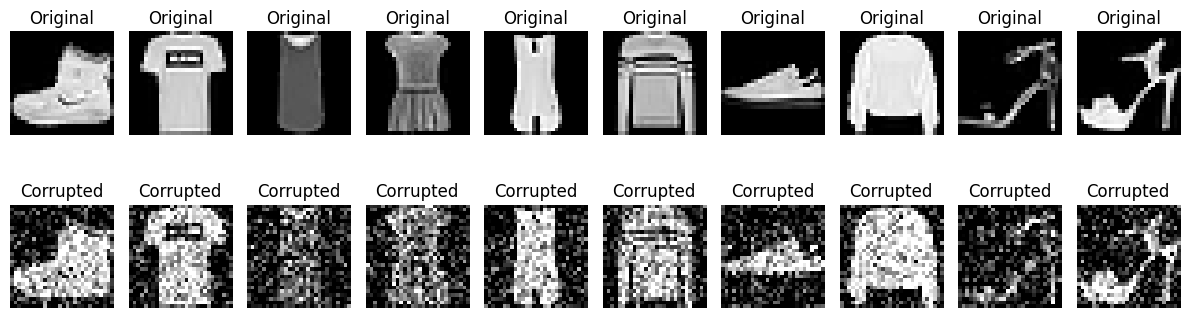

In [4]:
def show_corrupted_examples(clean, corrupted, n=10):
    plt.figure(figsize=(12, 4))
    for i in range(n):
        plt.subplot(2, n, i + 1)
        plt.imshow(clean[i].squeeze(), cmap="gray")
        plt.title("Original")
        plt.axis("off")

        plt.subplot(2, n, i + 1 + n)
        plt.imshow(corrupted[i].squeeze(), cmap="gray")
        plt.title("Corrupted")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_corrupted_examples(x_train, x_train_corrupt)


In [5]:
def psnr_metric(y_true, y_pred):
    return tf.image.psnr(y_true, y_pred, max_val=1.0)

### Convolutional Autoencoder Architecture (with skip connections)

In [6]:
def build_autoencoder():
    # Input 28x28 with 1 channel -> tensor 28x28x1
    inputs = Input(shape=(28, 28, 1))

    # ENCODER (Compression)

    # 1st block
    c1 = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    p1 = MaxPooling2D((2, 2), padding='same')(c1) # 14x14

    # 2nd block
    c2 = Conv2D(64, (3, 3), activation='relu', padding='same')(p1)
    p2 = MaxPooling2D((2, 2), padding='same')(c2) # 7x7

    # BOTTLENECK - latent representation - essential information
    b = Conv2D(128, (3, 3), activation='relu', padding='same')(p2)

    # DECODER (Reconstruction - skip connections)

    # Upsampling 1 + Concatenate with c2
    u1 = UpSampling2D((2, 2))(b) # Increase resolution - Repeats each pixel 2x2 times -> 14x14
    concat1 = Concatenate()([u1, c2]) # Concatenate with unput image - spatial details
    d1 = Conv2D(64, (3, 3), activation='relu', padding='same')(concat1)

    # Upsampling 2 + Concatenate with c1
    u2 = UpSampling2D((2, 2))(d1) # 28x28
    concat2 = Concatenate()([u2, c1])
    d2 = Conv2D(32, (3, 3), activation='relu', padding='same')(concat2)

    # OUTPUT should be 28x28 with 1 channel
    # Sigmoid - output between 0 and 1
    outputs = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(d2)

    # Create model
    model = Model(inputs, outputs)

    # Compile model
    model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_absolute_error', psnr_metric]
    )

    return model

autoencoder = build_autoencoder()
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 28, 28,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 14, 14,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 14, 14,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 7, 7, 64)  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 7, 7, 128) │     73,856 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 14, 14,    │          0 │ conv2d_2[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 14, 14,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 192)              │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 14, 14,    │    110,656 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 28, 28,    │          0 │ conv2d_3[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 28, 28,    │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 96)               │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 28, 28,    │     27,680 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 28, 28, 1) │        289 │ conv2d_4[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 231,297 (903.50 KB)

 Trainable params: 231,297 (903.50 KB)

 Non-trainable params: 0 (0.00 B)

### Model training

In [7]:
EPOCHS = 30
BATCH_SIZE = 128

# During 5 epochs loss does not decrease -> stop training
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print(f"\nStarting training for {EPOCHS} epochs...")

history = autoencoder.fit(
    x_train_corrupt, # Input = Corrupted image
    x_train, # Output = Restored image
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_test_corrupt, x_test),
    callbacks=[early_stop]
)

autoencoder.save(f'autoencoder_{TASK}_fashion_mnist_19_01_2026_modified_model.keras')
print("Model saved to Colab runtime.")


Starting training for 30 epochs...
Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - loss: 0.0134 - mean_absolute_error: 0.0664 - psnr_metric: 19.6237 - val_loss: 0.0092 - val_mean_absolute_error: 0.0530 - val_psnr_metric: 20.7059
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0085 - mean_absolute_error: 0.0507 - psnr_metric: 21.0595 - val_loss: 0.0082 - val_mean_absolute_error: 0.0494 - val_psnr_metric: 21.2284
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0080 - mean_absolute_error: 0.0484 - psnr_metric: 21.3612 - val_loss: 0.0079 - val_mean_absolute_error: 0.0481 - val_psnr_metric: 21.3992
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0077 - mean_absolute_error: 0.0470 - psnr_metric: 21.5476 - val_loss: 0.0076 - val_mean_absolute_error: 0.0463 - val_psnr_metric: 21.5660
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0075 - mean_absolute_error: 0.0461 - psnr_metric: 21.6830 - val_loss: 0.0075 - val_mean_absolute

### Training curves (loss & PSNR)

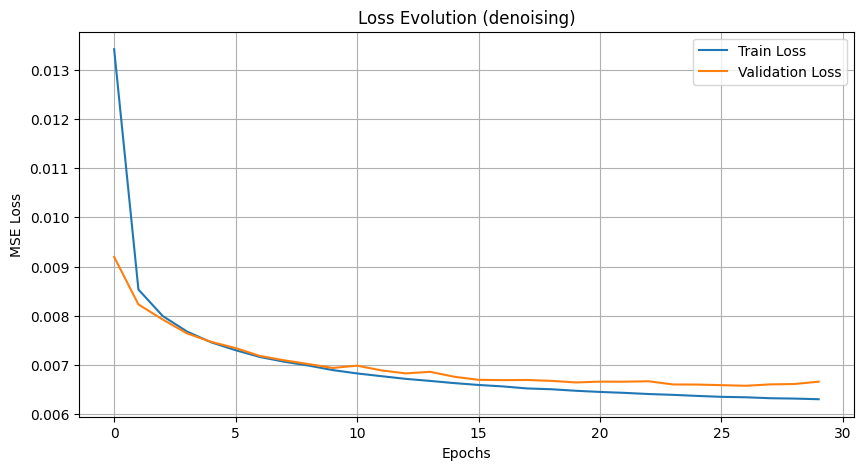

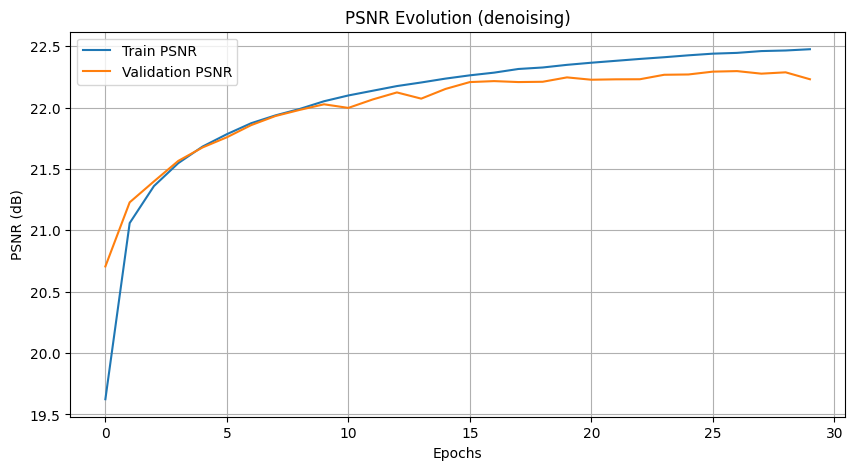

In [8]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title(f'Loss Evolution ({TASK})')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(10,5))
plt.plot(history.history['psnr_metric'], label='Train PSNR')
plt.plot(history.history['val_psnr_metric'], label='Validation PSNR')
plt.title(f'PSNR Evolution ({TASK})')
plt.xlabel('Epochs')
plt.ylabel('PSNR (dB)')
plt.legend()
plt.grid(True)
plt.show()

### Results & evaluation

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 977ms/step


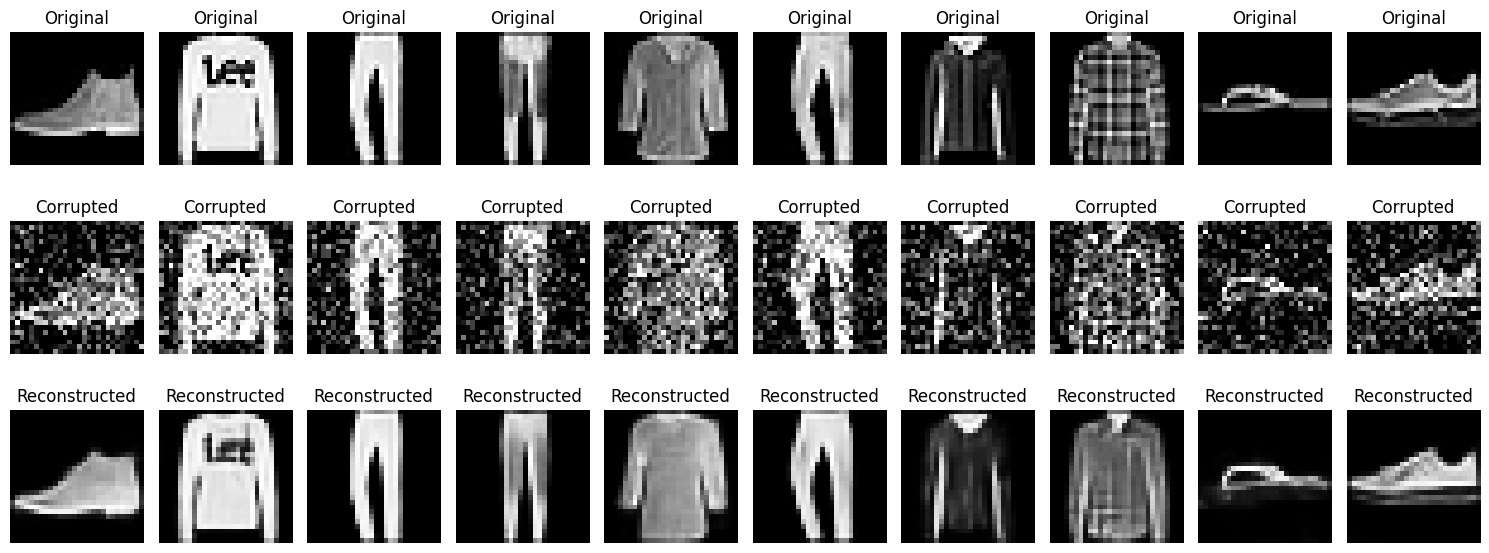

In [9]:
decoded_imgs = autoencoder.predict(x_test_corrupt[:10])

def plot_results(original, corrupted, reconstructed, n=10, title="Results"):
    fig = plt.figure(figsize=(15, 6))
    for i in range(n):
        # Original
        plt.subplot(3, n, i + 1)
        plt.imshow(original[i].squeeze(), cmap="gray")
        plt.title("Original")
        plt.axis("off")

        # Corrupted
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(corrupted[i].squeeze(), cmap="gray")
        plt.title("Corrupted")
        plt.axis("off")

        # Reconstructed
        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(reconstructed[i].squeeze(), cmap="gray")
        plt.title("Reconstructed")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

plot_results(
    x_test[:10],
    x_test_corrupt[:10],
    decoded_imgs[:10]
)

### MSE & PSNR

In [10]:
def psnr(original, reconstructed):
    # Compute MSE between original image and reconstructed
    mse = np.mean((original - reconstructed) ** 2)
    if mse == 0: # If reonstruction is perfect
      return float("inf") # tends to inf
    # PSNR formula
    return 20 * np.log10(1.0 / np.sqrt(mse))

# Compute global MSE (test set)
mse_value = np.mean((x_test[:len(decoded_imgs)] - decoded_imgs) ** 2)
# Compute PSNR
psnr_value = psnr(x_test[:len(decoded_imgs)], decoded_imgs)

print(f"Test MSE: {mse_value:.6f}")
print(f"PSNR: {psnr_value:.2f} dB")

Test MSE: 0.006520
PSNR: 21.86 dB


### Evaluation metrics

In [11]:
def calculate_metrics(original, reconstructed):
    print("Calculating metrics...")

    # PSNR
    psnr_values = tf.image.psnr(original, reconstructed, max_val=1.0)
    avg_psnr = tf.reduce_mean(psnr_values)

    # SSIM (Structural Similarity Index)
    ssim_values = tf.image.ssim(original, reconstructed, max_val=1.0)
    avg_ssim = tf.reduce_mean(ssim_values)

    return avg_psnr.numpy(), avg_ssim.numpy()

# Predictions for the entire test set
print("Generating predictions...")
all_decoded_imgs = autoencoder.predict(x_test_corrupt)

# Compute metrics
mean_psnr, mean_ssim = calculate_metrics(x_test, all_decoded_imgs)

print(f"RESULTS FOR {TASK.upper()}:\n")
print(f"Average PSNR: {mean_psnr:.2f} dB")
print(f"Average SSIM: {mean_ssim:.4f}")


Generating predictions...
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Calculating metrics...
RESULTS FOR DENOISING:

Average PSNR: 22.30 dB
Average SSIM: 0.7935


### Average Inference Time (processing time of one image)

Inference time measured on a single image (batch_size = 1)

In [12]:
import time

# Select 1 single image from test set
single_image = x_test_corrupt[0:1]

# Predict
_ = autoencoder.predict(single_image)

# Measure time for 100 predictions
start_time = time.time()
for _ in range(100):
    autoencoder.predict(single_image, verbose=0)
end_time = time.time()

# Compute avg
avg_time_sec = (end_time - start_time) / 100 # sec
avg_time_ms = avg_time_sec * 1000 # ms

print(f"Average Inference Time: {avg_time_ms:.2f} ms")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 606ms/step
Average Inference Time: 84.18 ms
